# Homework #4

## Regularization in Machine Learning

This colaboratory contains Homework #4 of the Machine Learning course, which is due **November 02, midnight (23:59 EEST time)**. To complete the homework, extract **(File -> Download .ipynb)** and submit to the course webpage.

## Submission's rules:

1.  Please, submit only .ipynb that you extract from the Colaboratory.
2.  Run your homework exercises before submitting (output should be present, preferably restart the kernel and press run all the cells).
3.  Do not change the description of tasks in red (even if there is a typo|mistake|etc).
4.  Please, make sure to avoid unnecessary long printouts.
5.  Each task should be solved right under the question of the task and not elsewhere.
6.  Solutions to both regular and bonus exercises should be submitted in one IPYNB file.

Please, steer clear of copying someone else's work. If you discuss assignments with anyone in the course, please, mention their names here:

1. Pooh


##List of Homework's exercises:

1.  [Ex1](#scrollTo=j5oTPhWPwHuP) - 4 points
2.  [Ex2](#scrollTo=Gqw_WFbk4izQ) - 6 points
3.  [Bonus 1](#scrollTo=jdZkblZW7bEp) - up to 4 points (based on quality of presentation)


## Homework exercise 1: Impact of Feature Selection and Regularisation on Logistic Regression Models (4 points)

<font color=''> In this exercise, you will explore how feature selection and regularisation affect the performance of logistic regression models. You will apply Lasso (L1 regularisation) for feature selection, train classification models with different settings, and evaluate their performance to identify signs of overfitting, underfitting, or achieving a good fit. </font>


In [337]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge, Lasso, LogisticRegression
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer


<font color=''> Here we will work with a new dataset called **SpeedDating**. This data was gathered from participants in experimental speed dating events from 2002-2004. During the events, the attendees would have a four-minute "first date" with every other participant of the opposite sex. At the end of their four minutes, participants were asked if they would like to see their date again. They were also asked to rate their date on six attributes: Attractiveness, Sincerity, Intelligence, Fun, Ambition, and Shared Interests. The dataset also includes questionnaire data gathered from participants at different points in the process. These fields include: demographics, dating habits, self-perception across key attributes, beliefs on what others find valuable in a mate, and lifestyle information.
You can find more detailed information on the attributes of this dataset via the link: https://www.openml.org/search?type=data&sort=nr_of_likes&status=active&id=40536.


In [338]:
# Fetching the dataset SpeedDating from OPENML library
dating = fetch_openml(data_id=40536)

In [339]:
dating.frame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8378 entries, 0 to 8377
Columns: 121 entries, has_null to match
dtypes: category(62), float64(57), int64(2)
memory usage: 4.3 MB


In [340]:
dating.data

,has_null,wave,gender,age,age_o,d_age,d_d_age,race,race_o,samerace,...,expected_num_interested_in_me,expected_num_matches,d_expected_happy_with_sd_people,d_expected_num_interested_in_me,d_expected_num_matches,like,guess_prob_liked,d_like,d_guess_prob_liked,met
0,0,1,female,21.0,27.0,6,[4-6],Asian/Pacific Islander/Asian-American,European/Caucasian-American,0,...,2.0,4.0,[0-4],[0-3],[3-5],7.0,6.0,[6-8],[5-6],0.0
1,0,1,female,21.0,22.0,1,[0-1],Asian/Pacific Islander/Asian-American,European/Caucasian-American,0,...,2.0,4.0,[0-4],[0-3],[3-5],7.0,5.0,[6-8],[5-6],1.0
2,1,1,female,21.0,22.0,1,[0-1],Asian/Pacific Islander/Asian-American,Asian/Pacific Islander/Asian-American,1,...,2.0,4.0,[0-4],[0-3],[3-5],7.0,NaN,[6-8],[0-4],1.0
3,0,1,female,21.0,23.0,2,[2-3],Asian/Pacific Islander/Asian-American,European/Caucasian-American,0,...,2.0,4.0,[0-4],[0-3],[3-5],7.0,6.0,[6-8],[5-6],0.0
4,0,1,female,21.0,24.0,3,[2-3],Asian/Pacific Islander/Asian-American,Latino/Hispanic American,0,...,2.0,4.0,[0-4],[0-3],[3-5],6.0,6.0,[6-8],[5-6],0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8373,1,21,male,25.0,26.0,1,[0-1],European/Caucasian-American,Latino/Hispanic American,0,...,NaN,3.0,[7-10],[0-3],[3-5],2.0,5.0,[0-5],[5-6],0.0
8374,1,21,male,25.0,24.0,1,[0-1],European/Caucasian-American,Other,0,...,NaN,3.0,[7-10],[0-3],[3-5],4.0,4.0,[0-5],[0-4],0.0
8375,1,21,male,25.0,29.0,4,[4-6],European/Caucasian-American,Latino/Hispanic American,0,...,NaN,3.0,[7-10],[0-3],[3-5],6.0,5.0,[6-8],[5-6],0.0
8376,1,21,male,25.0,22.0,3,[2-3],European/Caucasian-American,Asian/Pacific Islander/Asian-American,0,...,NaN,3.0,[7-10],[0-3],[3-5],5.0,5.0,[0-5],[5-6],0.0


<font color=''> We are trying to predict if it was a match (yes/no).


In [341]:
dating.target #labels

0       0
1       0
2       1
3       1
4       1
       ..
8373    0
8374    0
8375    0
8376    0
8377    0
Name: match, Length: 8378, dtype: category
Categories (2, object): ['0', '1']

<font color=''> **(Homework exercise 1- a)** To prepare the data for training, you need to complete several prepropressing steps: balance the dataset (use [`SMOTE`](https://imbalanced-learn.org/stable/over_sampling.html#)), handle numerical and categorical features (use `OneHotEncoder()` for categorical features and `StandardScaler()` for numerical), impute the missing values (use [`sklearn Simple Imputer`](https://scikit-learn.org/1.5/modules/impute.html)) and split into training and test sets. It is super important that you do these operations in the right order. </font>

<font color=''> We propose that you first split train and test, then impute missing data (feel free to use `mean` imputation strategy for numeric values and `most_frequent` for categorical). Next, you can balance your training data using SMOTENC (SMOTE for Numeric and Categorical data). Finally, you should perform one-hot encoding on categorical variables and do the scaling of numeric features both in train and test sets.

After doing all that, please answer the question below. **(1.5 points)** </font>


In [342]:
!pip install imbalanced-learn

In [343]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from imblearn.over_sampling import SMOTENC

#### YOUR CODE STARTS ####

# 1. Split the dataset
X = dating.data
y = dating.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Identify categorical and numerical features
categorical_features = X.select_dtypes(include=['object', 'category']).columns
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_indices = [X.columns.get_loc(col) for col in categorical_features]

# 2. Impute missing values
num_imputer = SimpleImputer(strategy='mean')
cat_imputer = SimpleImputer(strategy='most_frequent')

X_train[numerical_features] = num_imputer.fit_transform(X_train[numerical_features])
X_train[categorical_features] = cat_imputer.fit_transform(X_train[categorical_features])
X_test[numerical_features] = num_imputer.transform(X_test[numerical_features])
X_test[categorical_features] = cat_imputer.transform(X_test[categorical_features])

# 3. Balance the training data using SMOTENC
smote_nc = SMOTENC(categorical_features=categorical_indices, random_state=42)
X_train_res, y_train_res = smote_nc.fit_resample(X_train, y_train)

# 4. One-hot encode and scale
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

X_train_final = preprocessor.fit_transform(X_train_res)
X_test_final = preprocessor.transform(X_test)

y_train_final = y_train_res
y_test_final = y_test

#### YOUR CODE ENDS ####

<font color=''>**Question:** Suppose someone changes the order of preprocessing steps.
Give two examples of incorrect orderings (e.g. doing SMOTE before splitting, scaling before imputing, etc.) and explain why each would lead to unreliable results.</font>

**Answer:**...

When you apply SMOTE before splitting, your test set ends up containing synthetic samples generated using information from the training data. Basically, you’re validating on data the model has already seen during the training.


<font color=''> **(Homework exercise 1- b)** Perform feature selection using Lasso and print the names of the selected features.

TIPS: Because we work with classification, you cannot use LinearRegression with L1 regularisation, instead you can use LogisticRegression with L1. You can select the regularization parameter (in LogisticRegression called `C_value`) by trial-and error and see when the results seem reasonable, you don't have to do cross-validation here.
**(1 point)**</font>


Best C value: 10.0000
Validation accuracy: 0.8779
Selected features: 432

Selected features:
num__wave
num__age
num__age_o
num__d_age
num__importance_same_race
num__importance_same_religion
num__pref_o_attractive
num__pref_o_sincere
num__pref_o_intelligence
num__pref_o_funny
num__pref_o_ambitious
num__pref_o_shared_interests
num__attractive_o
num__sinsere_o
num__intelligence_o
num__funny_o
num__ambitous_o
num__shared_interests_o
num__attractive_important
num__sincere_important
num__intellicence_important
num__funny_important
num__ambtition_important
num__shared_interests_important
num__attractive
num__sincere
num__intelligence
num__funny
num__ambition
num__attractive_partner
num__sincere_partner
num__intelligence_partner
num__funny_partner
num__ambition_partner
num__shared_interests_partner
num__sports
num__tvsports
num__exercise
num__dining
num__museums
num__art
num__hiking
num__gaming
num__clubbing
num__reading
num__tv
num__theater
num__movies
num__concerts
num__music
num__shopping
n

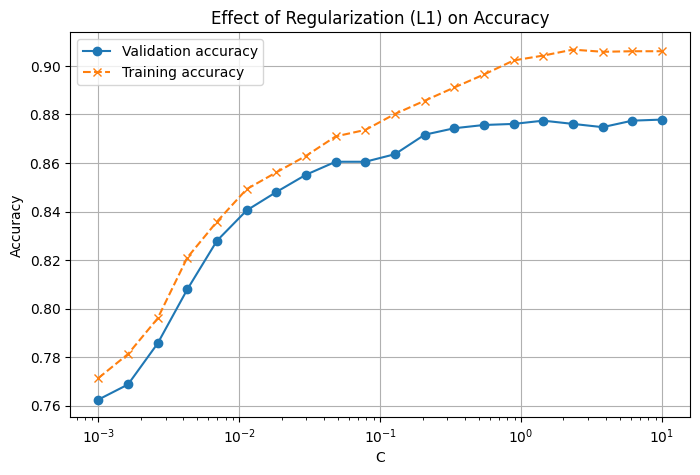

In [344]:
#### YOUR CODE STARTS ####
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X_subtrain, X_subtrain_val, y_subtrain, y_subtrain_val = train_test_split(
    X_train_final, y_train_final, test_size=0.2, random_state=42
)

C_values = np.logspace(-3, 1, 20)

train_scores = []
val_scores = []
n_features = []

for C in C_values:
    model = LogisticRegression(
        penalty='l1',
        solver='liblinear',
        C=C,
        max_iter=1000,
        random_state=42
    )
    model.fit(X_subtrain, y_subtrain)

    y_pred_train = model.predict(X_subtrain)
    y_pred_val = model.predict(X_subtrain_val)

    train_scores.append(accuracy_score(y_subtrain, y_pred_train))
    val_scores.append(accuracy_score(y_subtrain_val, y_pred_val))
    n_features.append(np.sum(model.coef_ != 0))


best_idx = np.argmax(val_scores)
best_C = C_values[best_idx]

print(f"Best C value: {best_C:.4f}")
print(f"Validation accuracy: {val_scores[best_idx]:.4f}")
print(f"Selected features: {n_features[best_idx]}")

best_model = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    C=best_C,
    max_iter=1000,
    random_state=42
)
best_model.fit(X_train_final, y_train_final)

feature_names = preprocessor.get_feature_names_out()
selected_features = feature_names[np.any(best_model.coef_ != 0, axis=0)]

print("\nSelected features:")
for f in selected_features:
    print(f)


plt.figure(figsize=(8,5))
plt.semilogx(C_values, val_scores, label='Validation accuracy', marker='o')
plt.semilogx(C_values, train_scores, label='Training accuracy', linestyle='--', marker='x')
plt.xlabel("C") # log scale
plt.ylabel("Accuracy")
plt.title("Effect of Regularization (L1) on Accuracy")
plt.legend()
plt.grid(True)
plt.show()

#plt.figure(figsize=(8,5))
#plt.semilogx(C_values, n_features, label='Selected features', color='purple', marker='o')
#plt.xlabel("C")
#plt.ylabel("Number of selected features")
#plt.title("Feature sparsity vs Regularization Strength")
#plt.grid(True)
#plt.legend()
#plt.show()




#### YOUR CODE ENDS ####

<font color=''> **(Homework exercise 1- c)** We want to understand if/how feature selection might have affected the results of the classification model. For this let's train four logistic regression models with and without extra regularisation. This time, unlike regularisation in the previous exercise, L2 is meant to reduce overfitting, not to help select features.

1.  Train on **all** features **without** L2 regularisation
2.  Train on **all** features **with** L2 regularisation
3.  Train on **selected** features (from your Lasso feature selection) **without** L2 regularisation
4.  Train on **selected** features (from your Lasso feature selection) **with** L2 regularisation  
    <font color=''>**(1 point)**</font>


In [345]:
# Model1: train on all features without L2 regularisation
#### YOUR CODE STARTS ####
model1 = LogisticRegression(penalty=None, max_iter=1000, random_state=42) # Default is 'lbfgs'.
model1.fit(X_train_final, y_train_final)

y_pred1 = model1.predict(X_test_final)
#### YOUR CODE ENDS ####

In [346]:
# Model2: train on all features with L2 regularisation
#### YOUR CODE STARTS ####
model2 = LogisticRegression(penalty='l2', solver='lbfgs', max_iter=1000, random_state=42) # C=10,
model2.fit(X_train_final, y_train_final)
y_pred2 = model2.predict(X_test_final)
#### YOUR CODE ENDS ####

In [347]:
# Select features, removing unselected ones
X_train_selected = X_train_final[:, np.any(best_model.coef_ != 0, axis=0)]  # remaining features after L1 regularization
X_test_selected = X_test_final[:, np.any(best_model.coef_ != 0, axis=0)]  	# remaining features after L1 regularization

In [348]:
# Model3: train on selected features without L2 regularisation
#### YOUR CODE STARTS ####
model3 = LogisticRegression(penalty=None, max_iter=1000, random_state=42)
model3.fit(X_train_selected, y_train_final)
y_pred3 = model3.predict(X_test_selected)
#### YOUR CODE ENDS ####

In [349]:
# Model4: train on selected features with L2 regularisation
#### YOUR CODE STARTS ####
model4 = LogisticRegression(penalty='l2',  solver='lbfgs', max_iter=1000, random_state=42) #C=10.0,
model4.fit(X_train_selected, y_train_final)
y_pred4 = model4.predict(X_test_selected)
#### YOUR CODE ENDS ####

<font color=''> **(Homework exercise 1- d)** Concisely report the accuracies on both training and test sets for all four models from **1-c**. Compare the results across all models. In a separate print statement comment whether any models exhibit overfitting, underfitting, or a normal fit (add reasoning). **(0.5 points)**


In [350]:
accuracy_score(y_test_final, model1.predict(X_test_final))

0.8144391408114559

In [351]:
accuracy_score(y_test, y_pred1)

0.8144391408114559

In [352]:
from sklearn.metrics import accuracy_score

models = [model1, model2, model3, model4]
model_names = [
    "All features, no L2",
    "All features, with L2",
    "Selected features, no L2",
    "Selected features, with L2"
]

print("Training and Test Accuracies:\n")

for idx, model in enumerate(models, start=1):
    y_tr_pred = model.predict(X_train_final if idx <= 2 else X_train_selected)
    y_te_pred = model.predict(X_test_final if idx <= 2 else X_test_selected)

    train_acc = accuracy_score(y_train_final, y_tr_pred)
    test_acc = accuracy_score(y_test_final, y_te_pred)

    print(f"{model_names[idx-1]}:")
    print(f"  Training Accuracy: {train_acc:.4f}")
    print(f"  Test Accuracy:     {test_acc:.4f}\n")


Training and Test Accuracies:

All features, no L2:
  Training Accuracy: 0.9031
  Test Accuracy:     0.8144

All features, with L2:
  Training Accuracy: 0.8987
  Test Accuracy:     0.8144

Selected features, no L2:
  Training Accuracy: 0.9033
  Test Accuracy:     0.8150

Selected features, with L2:
  Training Accuracy: 0.8990
  Test Accuracy:     0.8156



<font color=''> Please comment whether any models exhibit overfitting, underfitting, or a normal fit (add reasoning).


Your answer:


Models without L2 show slight overfitting.

Models with L2, especially combined with selected features, achieve more normal(ish) fit (training and test accuracies are more close to each other).

None of the models exhibit underfitting (training and test accuracies are reasonably high).


In [353]:
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf

import matplotlib.pyplot as plt
import seaborn as sns

import os
from PIL import Image # Python Image processing Library

from tensorflow.keras.layers import Input, Conv2D, Activation, Flatten, Dense, MaxPooling2D, BatchNormalization, Dropout, Normalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

## Homework exercise 2 (6 points): Traffic signs classification

<font color=''> In the practice session, we were focusing mostly on explicit regularization methods - making changes in model's architecture. Now, in this exercise we will take a different approach - we will transform the dataset instead. Since our beloved MNIST and CIFAR10 are designed in a very nice balanced way, we are introducing a new, trickier dataset for this task - the Belgium Traffic Sign dataset ([BelgiumTSC](https://btsd.ethz.ch/shareddata/)). Our goal here is to classify the traffic signs.


<font color=''> Firstly, we load the data from Google Drive.


In [354]:
!pip install gdown

In [355]:
!gdown --fuzzy https://drive.google.com/file/d/1gCq2h-BX0CPHlfbTDEWa0Lzb26ryqQYH/view?usp=sharing

Downloading...
From (original): https://drive.google.com/uc?id=1gCq2h-BX0CPHlfbTDEWa0Lzb26ryqQYH
From (redirected): https://drive.google.com/uc?id=1gCq2h-BX0CPHlfbTDEWa0Lzb26ryqQYH&confirm=t&uuid=d4261406-70ab-4bcb-8c2b-a2c8a3a19b19
To: /gpfs/helios/home/etais/hpc_saskia/BelgiumTSC.zip
100%|██████████████████████████████████████| 49.4M/49.4M [00:00<00:00, 73.3MB/s]


In [356]:
!pwd

/gpfs/helios/home/etais/hpc_saskia


In [357]:
!unzip -o -q BelgiumTSC.zip -d data/

<font color='red'> The contents of archive contain 62 folders with .png images of traffic signs and an annotations file with labels and coordinates of signs (we won't use the coordinates as we are interested only in classification).


In [358]:
!ls data/BelgiumTSC/

00000  00007  00014  00021  00028  00035  00042  00049	00056
00001  00008  00015  00022  00029  00036  00043  00050	00057
00002  00009  00016  00023  00030  00037  00044  00051	00058
00003  00010  00017  00024  00031  00038  00045  00052	00059
00004  00011  00018  00025  00032  00039  00046  00053	00060
00005  00012  00019  00026  00033  00040  00047  00054	00061
00006  00013  00020  00027  00034  00041  00048  00055	annotations.csv


In [359]:
!ls  data/BelgiumTSC/00000

00017_00001.png  01153_00002.png  01797_00000.png  01799_00002.png
00021_00000.png  01160_00000.png  01798_00000.png


<font color=''> We can also take a look at a single image.


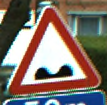

In [360]:
Image.open('./data/BelgiumTSC/00000/01153_00002.png')

In [361]:
# A path to our dataset
dataset_path = './data/BelgiumTSC/'

In [362]:
# Read a csv file with annotations
annt_df = pd.read_csv(os.path.join(dataset_path, 'annotations.csv'))
annt_df.head()

,Filepath,Width,Height,Roi.x1,Roi.y1,Roi.x2,Roi.y2,ClassId
0,00000/01153_00002.png,105,107,9,9,96,98,0
1,00000/01160_00000.png,94,105,8,9,86,95,0
2,00000/01797_00000.png,85,95,7,8,77,87,0
3,00000/01798_00000.png,81,88,7,7,74,81,0
4,00000/01799_00002.png,99,110,8,9,91,100,0


<font color=''> Notice that the images have different widths and heights. We will deal with this issue later.

<font color=''> Roi.x1, Roi.y1, Roi.x2, and Roi.y2—represent the coordinates of a bounding box that highlights the most relevant or important part of each image. For this homework we will not use the ROI information because our focus here is on the overall image properties and not on extracting important regions.


<font color=''>Before loading any images, let's plot the distribution of images per class.


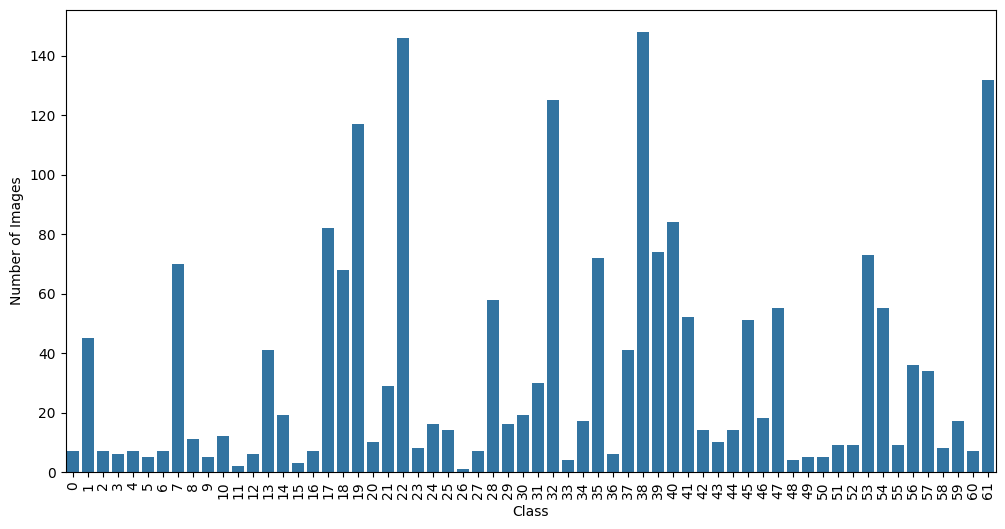

In [363]:
plt.figure(figsize=(12, 6))
sns.countplot(x='ClassId', data=annt_df)
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=90)
plt.show()

<font color=''> The dataset is heavily unbalanced, with the largest class containing 70 times more images than the smallest one. To make our lives a bit easier, we will remove any classes that have fewer than 8 images.


<font color=''> **(Homework exercise 2- a)** Drop rows from the DataFrame where the image class has fewer than 8 samples (i.e., images). Then, rename the remaining classes to ensure that the class labels are sequential with no gaps in the numbering. Explain why 8 was chosen as the minimum number of samples for an image class. **(1 point)**. </font>


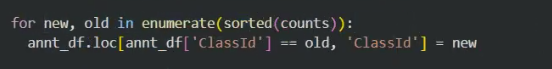

i should have recalclulated 'ClassId'-s after dropping rows with less than 8 samples.


In [364]:
##### YOUR CODE STARTS #####

class_counts = annt_df['ClassId'].value_counts()
valid_classes = class_counts[class_counts >= 8].index

df_dropped = annt_df[annt_df['ClassId'].isin(valid_classes)].copy()

##### YOUR CODE ENDS #####

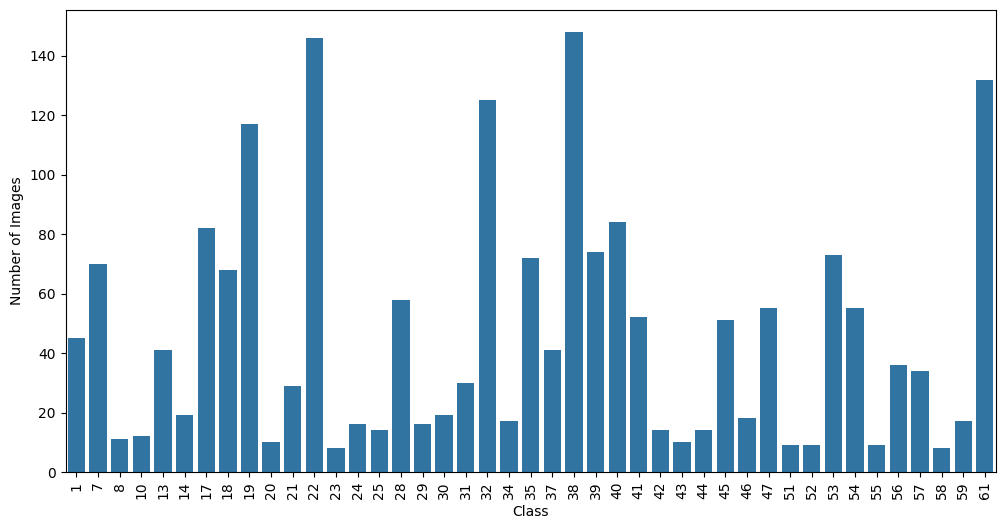

In [365]:
plt.figure(figsize=(12, 6))
sns.countplot(x='ClassId', data=df_dropped)
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=90)
plt.show()

<font color=''> Explain the rationale behind removing image classes with fewer than 8 samples from the dataset. How this decision may relate to the upcoming split of our dataset into training, validation, and test sets?


Your answer:

Classes with fewer than 8 samples are removed because there is not enough data to effectively train a model on these classes. When the dataset is later split into training, validation, and test sets, having very few samples per class could result in overfitting for those classes, as the model may memorize the limited examples rather than learning generalizable features.


<font color=''> **(Homework exercise 2- b)** Split the data into three sets: training, validation and test with 80/10/10 ratio. Make sure that all classes are represented in both the validation and test sets. **(0.5 points)**. </font>


In [366]:
from sklearn.model_selection import train_test_split

##### YOUR CODE STARTS #####

X = df_dropped.drop(columns=['ClassId'])  # features
y = df_dropped['ClassId']                 # labels


train_df, temp_df = train_test_split(
    df_dropped, test_size=0.2, stratify=df_dropped['ClassId'], random_state=42
)


val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['ClassId'], random_state=42
)

print("Train:", len(train_df), "Validation:", len(val_df), "Test:", len(test_df))

##### YOUR CODE ENDS #####

Train: 1574 Validation: 197 Test: 197


In [367]:
# Check whether all classes are present in val and test sets

assert len(train_df['ClassId'].unique()) == len(val_df['ClassId'].unique())
assert len(train_df['ClassId'].unique()) == len(test_df['ClassId'].unique())

<font color=''> Now, we are ready to read in the actual images and do simple preprocessing on them, such as resize all images into 100x100 shape and then normalize them. This code is provided for you.


In [368]:
def load_image(image_path):
  # Load the image
  image = Image.open(image_path)

  # Resize the image
  image = image.resize((100, 100))

  # Normalize the image
  image = np.array(image) / 255.0 # basic normalisation

  return image

In [369]:
X_train, X_val, X_test = [], [], []

# Load images from the dataset
for i, row in train_df.iterrows():
  X_train.append(load_image(dataset_path + row['Filepath']))

for i, row in val_df.iterrows():
  X_val.append(load_image(dataset_path + row['Filepath']))

for i, row in test_df.iterrows():
  X_test.append(load_image(dataset_path + row['Filepath']))

# Convert the lists of images to numpy arrays for easier manipulation
X_train = np.stack(X_train)
X_val = np.stack(X_val)
X_test = np.stack(X_test)

# Extract the class labels for training, validation, and test sets
y_train = train_df['ClassId'].values
y_val = val_df['ClassId'].values
y_test = test_df['ClassId'].values

In [370]:
# Take a look at shapes:
X_train.shape, y_train.shape

((1574, 100, 100, 3), (1574,))

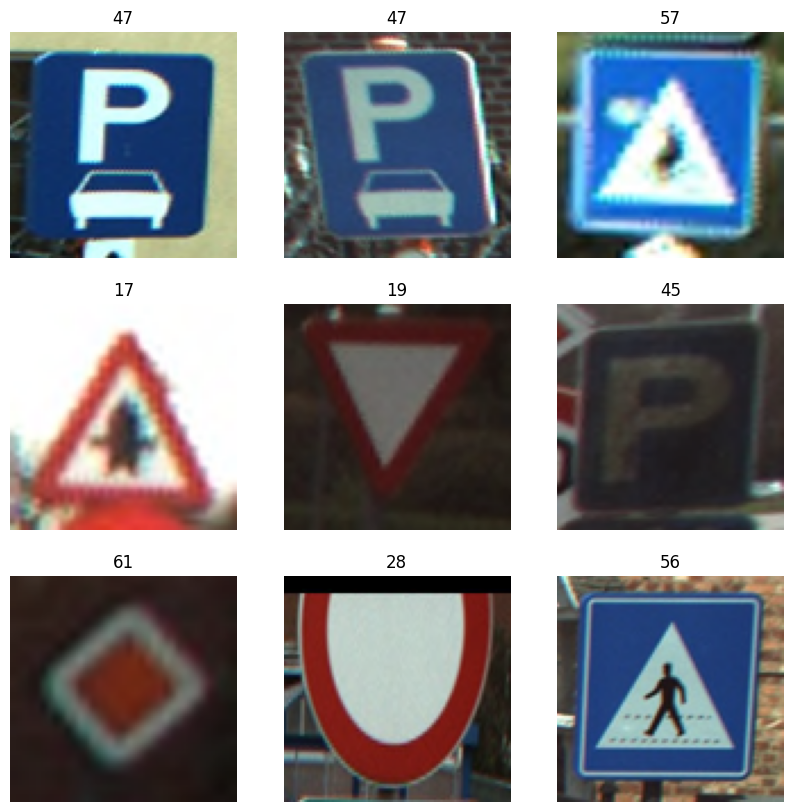

In [371]:
# Visualise nine random images
plt.figure(figsize=(10, 10))

for i in range(9):
    indx = np.random.randint(0, len(X_train))
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow((X_train[indx] * 255).astype('uint8'))
    plt.title(y_train[indx])
    plt.axis("off")

<font color=''> **(Homework exercise 2- c)** Use your best-performing model from Task 2 of Homework 3 to train on the traffic sign image dataset. Plot the learning curves to visualize the model’s performance over time. Adjust the number of training epochs so that the process stops when the validation loss no longer improves. **(1 point)**. </font>


In [372]:
# remap labels
unique_labels = np.unique(y_train)
label_map = {label: idx for idx, label in enumerate(unique_labels)}
y_train_mapped = np.array([label_map[y] for y in y_train])
y_val_mapped   = np.array([label_map[y] for y in y_val])

In [373]:
num_classes = len(np.unique(y_train_mapped))

def build_model():
  ##### YOUR CODE STARTS #####
  x = Input(shape=(100, 100, 3)) # Resized from 32x32 to 100x100, because the images are larger in this dataset

  # First conv block
  c1 = Conv2D(32, (3, 3), padding="same")(x)
  b1 = BatchNormalization()(c1)
  a1 = Activation('relu')(b1)

  # Second conv block
  c2 = Conv2D(32, (3, 3), padding="same")(a1)
  b2 = BatchNormalization()(c2)
  a2 = Activation('relu')(b2)

  # Third conv block
  c3 = Conv2D(32, (3, 3), padding="valid")(a2)
  b3 = BatchNormalization()(c3)
  a3 = Activation('relu')(b3)

  p3 = MaxPooling2D(pool_size=2)(a3)
  d3 = Dropout(rate=0.25)(p3)

  # Flatten + dense
  f = Flatten()(d3)
  h = Dense(100)(f)
  b4 = BatchNormalization()(h)
  a4 = Activation('relu')(b4)
  d4 = Dropout(rate=0.5)(a4)

  # Output layer
  z = Dense(num_classes)(d4) # changed from 10 to num_classes
  p = Activation('softmax')(z)

  model = Model(inputs=x, outputs=p)
  model.compile(
      loss='sparse_categorical_crossentropy',
      optimizer=Adam(learning_rate=1e-4),
      metrics=['accuracy']
  )
  return model
  ##### YOUR CODE ENDS #####

In [374]:
model1 = build_model()
model1.summary()

Model: "functional_75878"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_35 (InputLayer)     │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_107 (Conv2D)             │ (None, 100, 100, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_148         │ (None, 100, 100, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_186 (Activation)     │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_108 (Conv2D)             │ (None, 100, 100, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_149         │ (None, 100, 100, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_187 (Activation)     │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_109 (Conv2D)             │ (None, 98, 98, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_150         │ (None, 98, 98, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_188 (Activation)     │ (None, 98, 98, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_38 (MaxPooling2D) │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_76 (Dropout)            │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_38 (Flatten)            │ (None, 76832)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_76 (Dense)                │ (None, 100)            │     7,683,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_151         │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_189 (Activation)     │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_77 (Dropout)            │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_77 (Dense)                │ (None, 43)             │         4,343 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_190 (Activation)     │ (None, 43)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,707,819 (29.40 MB)

 Trainable params: 7,707,427 (29.40 MB)

 Non-trainable params: 392 (1.53 KB)

In [375]:
histories = []

In [376]:
print(X_train.shape, y_train.shape)
print(np.min(X_train), np.max(X_train))
print(np.unique(y_train))


(1574, 100, 100, 3) (1574,)
0.0 1.0
[ 1  7  8 10 13 14 17 18 19 20 21 22 23 24 25 28 29 30 31 32 34 35 37 38
 39 40 41 42 43 44 45 46 47 51 52 53 54 55 56 57 58 59 61]


In [ ]:
# Train your model. IMPORTANT: If you decide to resume training, ensure that you
# correctly set the initial_epoch parameter to continue from where training left
# off.
##### YOUR CODE STARTS #####
...
# initial_epoch, is a parameter that sets the epoch at which to start training
# (useful for resuming a previous training run).


history = model1.fit(
	X_train,
	y_train_mapped,
	batch_size=64,
	epochs=50,
	validation_split=0.1,
	initial_epoch=histories[-1].epoch[-1] if histories else 0,
	#validation_data=(X_val, y_val_mapped) Should we use validation data here instead of validation_split?
	)


##### YOUR CODE ENDS #####

histories.append(history) # In case you want to continue training but don't want
                          # to loose the training history

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 214ms/step - accuracy: 0.2691 - loss: 3.1091 - val_accuracy: 0.2532 - val_loss: 3.6049
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5798 - loss: 1.8674 - val_accuracy: 0.1899 - val_loss: 3.6097
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7712 - loss: 1.3144 - val_accuracy: 0.1456 - val_loss: 3.6091
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8496 - loss: 1.0264 - val_accuracy: 0.0696 - val_loss: 3.5781
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9145 - loss: 0.8352 - val_accuracy: 0.1013 - val_loss: 3.4872
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9400 - loss: 0.6790 - val_accuracy: 0.0949 - val_loss: 3.4110
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9597 - loss: 0.5958 - val_accuracy: 0.1203 - val_loss: 3.2908
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9696 - loss: 0.5196 - val_accuracy: 0.3481 -

In [378]:
def plot_history(histories):
    combined_loss = []
    combined_val_loss = []
    combined_accuracy = []
    combined_val_accuracy = []

    for history in histories:
        combined_loss.extend(history.history['loss'])
        combined_val_loss.extend(history.history['val_loss'])
        combined_accuracy.extend(history.history['accuracy'])
        combined_val_accuracy.extend(history.history['val_accuracy'])

    epochs = range(1, len(combined_loss) + 1)

    plt.figure(figsize=(16, 6))

    # Plot for Loss
    plt.subplot(1, 2, 1)
    plt.plot(combined_loss)
    plt.plot(combined_val_loss)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend(['Training', 'Validation'])
    plt.title('Loss')
    plt.xticks(range(len(combined_loss)), epochs)

    # Plot for Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(combined_accuracy)
    plt.plot(combined_val_accuracy)
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend(['Training', 'Validation'])
    plt.title('Accuracy')
    plt.xticks(range(len(combined_accuracy)), epochs)

    plt.show()

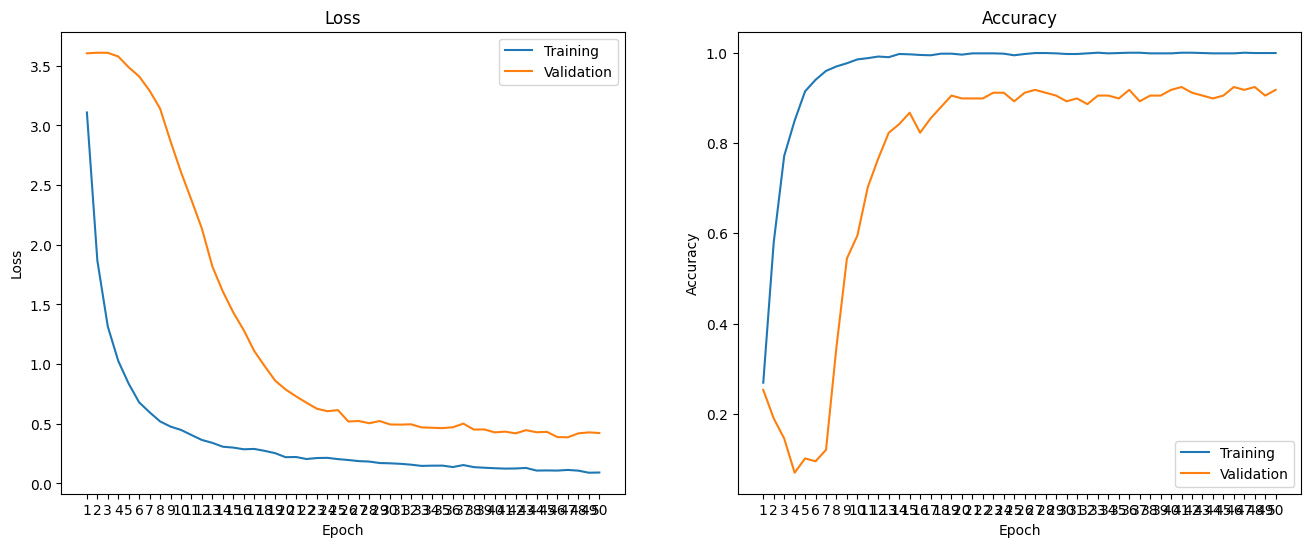

In [379]:
plot_history(histories)

<font color=''> **(Homework exercise 2- d)**
Evaluate the model by calculating the overall accuracy as well as the accuracy for each individual class on the test set **(0.5 points)**.</font>


In [380]:
def get_predictions(model, X):

  # Make predictions
  y_pred = model.predict(X, batch_size = 64)
  # Convert the predicted probabilities to class labels by
  # taking the index of the highest value for each prediction
  y_pred = np.argmax(y_pred, axis=1)

  return y_pred

In [381]:
y_test_predictions = get_predictions(model1, X_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 160ms/step


In [382]:
unique_labels = np.unique(y_test)
label_map = {label: idx for idx, label in enumerate(unique_labels)}
y_test_mapped = np.array([label_map[y] for y in y_test])

In [383]:
# Calulate the overall accuracy on test set
##### YOUR CODE STARTS #####

test_accuracy = np.mean(y_test_predictions == y_test_mapped)

#test_accuracy = model1.evaluate(X_test, y_test_mapped, verbose=0)[1]


##### YOUR CODE ENDS #####
print(f'Test accuracy is {test_accuracy:.2f}') # It should be about 90%

Test accuracy is 0.94


In [384]:

test_accuracy = accuracy_score(y_test_mapped, y_test_predictions)

In [385]:
test_accuracy

0.9390862944162437

In [386]:
# Calulate accuracy for each individual class on test set
def per_class_accuracy_score(predictions, labels):
  ##### YOUR CODE STARTS #####
  class_accuracies = {}
  unique_classes = np.unique(labels)
  for cls in unique_classes:
      cls_indices = np.where(labels == cls)[0]
      cls_accuracy = np.mean(predictions[cls_indices] == labels[cls_indices])
      class_accuracies[cls] = cls_accuracy
  return class_accuracies
  ##### YOUR CODE ENDS #####

In [387]:
# Print out computed accuracies
per_class_accuracy_score(y_test_predictions, y_test_mapped)

{np.int64(0): np.float64(1.0),
 np.int64(1): np.float64(0.8571428571428571),
 np.int64(2): np.float64(1.0),
 np.int64(3): np.float64(1.0),
 np.int64(4): np.float64(1.0),
 np.int64(5): np.float64(1.0),
 np.int64(6): np.float64(1.0),
 np.int64(7): np.float64(0.7142857142857143),
 np.int64(8): np.float64(0.9166666666666666),
 np.int64(9): np.float64(1.0),
 np.int64(10): np.float64(1.0),
 np.int64(11): np.float64(1.0),
 np.int64(12): np.float64(1.0),
 np.int64(13): np.float64(0.5),
 np.int64(14): np.float64(1.0),
 np.int64(15): np.float64(1.0),
 np.int64(16): np.float64(1.0),
 np.int64(17): np.float64(1.0),
 np.int64(18): np.float64(1.0),
 np.int64(19): np.float64(0.9166666666666666),
 np.int64(20): np.float64(1.0),
 np.int64(21): np.float64(1.0),
 np.int64(22): np.float64(1.0),
 np.int64(23): np.float64(0.9333333333333333),
 np.int64(24): np.float64(1.0),
 np.int64(25): np.float64(1.0),
 np.int64(26): np.float64(1.0),
 np.int64(27): np.float64(1.0),
 np.int64(28): np.float64(1.0),
 np.int

<font color=''> For how many classes your model showed zero accuracy?


Your answer:

5 classes showed zero accuracy.


<font color=''> **(Homework exercise 2- e)** Implement a basic oversampling strategy by duplicating images until each class has at least `n` samples in the training set. Choose `n` yourself. Train the model on oversampled training set and evaluate on the test set. Adjust the number of epochs so that the training stops when the validation loss stops improving. **(1.5 points)**. </font>


In [388]:
def oversample_minority_classes(df, n):
  ##### YOUR CODE STARTS #####
  class_counts = df['ClassId'].value_counts()
  minority_classes = class_counts[class_counts < n].index
  for cls in minority_classes:
      current_count = class_counts[cls]
      samples_needed = n - current_count
      samples_to_add = df[df['ClassId'] == cls].sample(samples_needed, replace=True, random_state=42)
      df = pd.concat([df, samples_to_add], ignore_index=True)
  return df
  ##### YOUR CODE ENDS #####

In [389]:
# Now choose value n wisely

# im actually doing under+oversampling to balance the classes

#n = train_df['ClassId'].value_counts().min()
#or mean
#n = int(np.mean(train_df['ClassId'].value_counts()))

# im doing only oversampling here
n = train_df['ClassId'].value_counts().max()

oversampled_train_df = oversample_minority_classes(train_df, n = n)

In [390]:
n

np.int64(118)

In [391]:
len(oversampled_train_df)

5074

<font color=''> What value of `n` did you choose and why?


Your answer:
it was said that i should only do oversampling, so i chose n as the maximum number of samples in a class to balance the classes.

otherwise i would have chosen under+oversampling to balance the classes by choosing n as the mean number of samples in a class.


In [392]:
X_train_oversampled = []

for i, row in oversampled_train_df.iterrows():
  X_train_oversampled.append(load_image(dataset_path + row['Filepath']))

X_train_oversampled = np.stack(X_train_oversampled)

y_train_oversampled = oversampled_train_df['ClassId'].values

In [393]:
# We use the same model as in subtask 2-c
model2 = build_model()

In [394]:
histories_2 = []

In [395]:
unique_labels = np.unique(y_train_oversampled)
label_map = {label: idx for idx, label in enumerate(unique_labels)}

In [396]:
y_train_mapped = np.array([label_map[y] for y in y_train_oversampled])

In [397]:
# Train your model2 with a new oversampled dataset

##### YOUR CODE STARTS #####
history = model2.fit(
	X_train_oversampled,
	np.array([label_map[y] for y in y_train_oversampled]),
	batch_size=64,
	epochs=20,
	validation_split=0.1,
	initial_epoch=histories_2[-1].epoch[-1] if histories_2 else 0
	)
##### YOUR CODE ENDS #####

histories_2.append(history) # In case you want to continue training the model
# for more epochs but don't want to loose the training history

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 11s 75ms/step - accuracy: 0.5604 - loss: 1.9534 - val_accuracy: 0.0000e+00 - val_loss: 3.8872
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9448 - loss: 0.7215 - val_accuracy: 0.0000e+00 - val_loss: 3.8548
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9788 - loss: 0.4808 - val_accuracy: 0.1220 - val_loss: 3.4477
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9899 - loss: 0.3579 - val_accuracy: 0.3740 - val_loss: 2.8334
Epoch 5/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9952 - loss: 0.2851 - val_accuracy: 0.8031 - val_loss: 1.9845
Epoch 6/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9974 - loss: 0.2413 - val_accuracy: 0.9665 - val_loss: 1.1708
Epoch 7/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9978 - loss: 0.2120 - val_accuracy: 1.0000 - val_loss: 0.7561
Epoch 8/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9980 - loss: 0.1923 - val_accuracy: 1

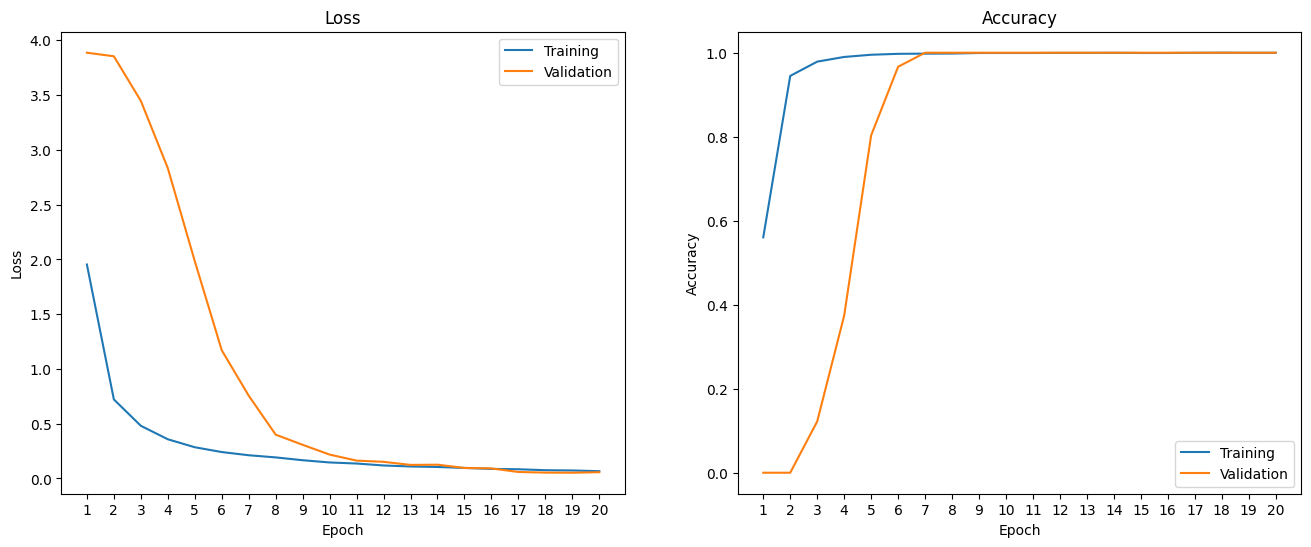

In [398]:
plot_history(histories_2)

In [399]:
y_test_predictions = get_predictions(model2, X_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 160ms/step


In [400]:
# Calulate the overall accuracy on test set
##### YOUR CODE STARTS #####
test_accuracy = np.mean(y_test_predictions == y_test_mapped)
##### YOUR CODE ENDS #####
print(f'Test accuracy is {test_accuracy:.2f}')

Test accuracy is 0.92


In [401]:
# Accuracy for each individual class on test set
per_class_accuracy_score(y_test_predictions, y_test_mapped)

{np.int64(0): np.float64(1.0),
 np.int64(1): np.float64(0.7142857142857143),
 np.int64(2): np.float64(1.0),
 np.int64(3): np.float64(1.0),
 np.int64(4): np.float64(1.0),
 np.int64(5): np.float64(1.0),
 np.int64(6): np.float64(0.875),
 np.int64(7): np.float64(0.8571428571428571),
 np.int64(8): np.float64(0.9166666666666666),
 np.int64(9): np.float64(1.0),
 np.int64(10): np.float64(1.0),
 np.int64(11): np.float64(0.9333333333333333),
 np.int64(12): np.float64(1.0),
 np.int64(13): np.float64(0.5),
 np.int64(14): np.float64(1.0),
 np.int64(15): np.float64(1.0),
 np.int64(16): np.float64(1.0),
 np.int64(17): np.float64(0.5),
 np.int64(18): np.float64(1.0),
 np.int64(19): np.float64(0.9166666666666666),
 np.int64(20): np.float64(1.0),
 np.int64(21): np.float64(1.0),
 np.int64(22): np.float64(1.0),
 np.int64(23): np.float64(0.9333333333333333),
 np.int64(24): np.float64(1.0),
 np.int64(25): np.float64(1.0),
 np.int64(26): np.float64(1.0),
 np.int64(27): np.float64(0.0),
 np.int64(28): np.floa

<font color=''> For how many classes your model showed zero accuracy? Is the number smaller than in EX2-d?


Your answer:
its sligthy better, 4 class showed zero accuracy.

Since some images are essentially duplicates, it makes sense that the accuracy for certain classes may even decrease. Some specialized neurons might memorize these repeated images, which can hurt the model’s ability to generalize to the test set.


<font color=''> **(Homework exercise 2- f)** Add three augmentations to the oversampled training data. Think about reasonable augmentations for this dataset. You can use either `tf.keras.preprocessing.image.ImageDataGenerator` as we did in practice session or add augmentation layers from https://keras.io/api/layers/preprocessing_layers/image_augmentation/ on top of your model. Train the model on augmented data and evaluate it. Again, adjust the number of epochs so that the training stops when the validation loss stops improving. **(1.5 points)**. </font>


In [402]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
##### YOUR CODE STARTS #####
datagen = ImageDataGenerator(
	rotation_range=15,
	width_shift_range=0.1,
	height_shift_range=0.1,
	zoom_range=0.1,
	horizontal_flip=True,
)
##### YOUR CODE ENDS #####

<font color=''> Make sure that the augmentations aren't too strong and do not distort the images too much.


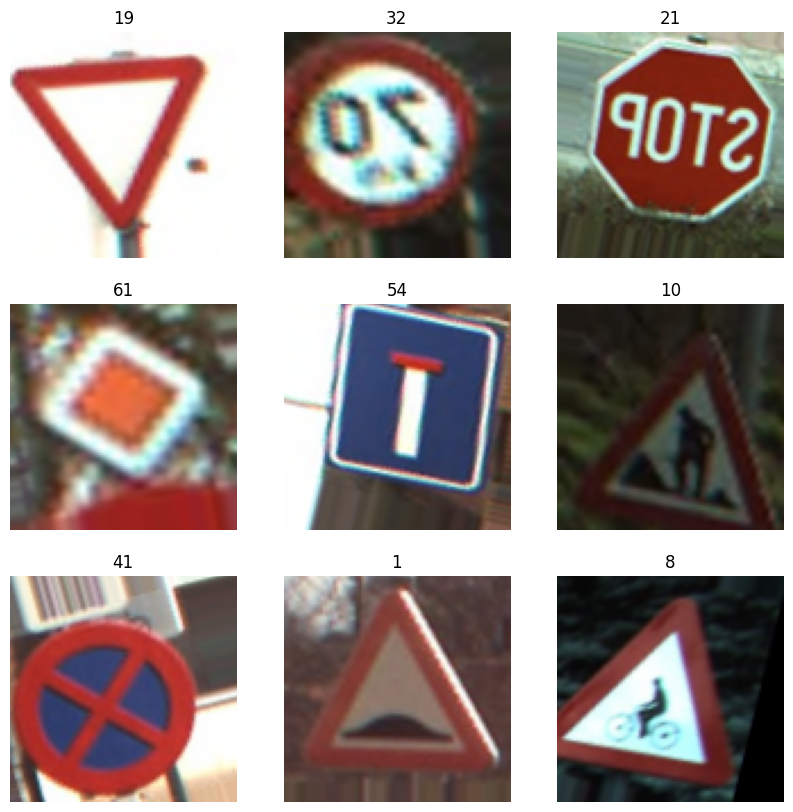

In [403]:
plt.figure(figsize=(10, 10))

for X_batch, y_batch in datagen.flow(X_train_oversampled, y_train_oversampled, batch_size=9):
    # Show 9 images
    for i in range(0, 9):
        plt.subplot(3, 3, 1 + i)
        plt.imshow((X_batch[i] * 255).astype('uint8'))
        plt.title(y_batch[i])
        plt.axis('off')
    # show the plot
    plt.show()
    break

<font color=''> Explain why did you choose these augmentations.


Your answer:

i chose rotation, width and height shift, zoom and horizontal flip because traffic signs can be seen from different angles, distances and positions in real life driving scenarios. These augmentations help the model generalize better to such variations.


In [404]:
# We use the same model as in subtask 2-c
model3 = build_model()

In [405]:
histories_3 = []

In [406]:
unique_labels = np.unique(y_train_oversampled)
label_map = {label: idx for idx, label in enumerate(unique_labels)}
y_train_mapped = np.array([label_map[y] for y in y_train_oversampled])

In [409]:
# Train your model3 with an augmented data
##### YOUR CODE STARTS #####

from tensorflow.keras.callbacks import EarlyStopping


early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)


history = model3.fit(
	datagen.flow(X_train_oversampled, y_train_mapped, batch_size=64),
	steps_per_epoch=len(X_train_oversampled) // 64,
	epochs=500,
	callbacks=[early_stop],
	validation_data=(X_val, y_val_mapped),
	#initial_epoch=histories_3[-1].epoch[-1] if histories_3 else 0
	)
##### YOUR CODE ENDS #####

histories_3.append(history)

Epoch 1/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 10s 132ms/step - accuracy: 0.4142 - loss: 2.2436 - val_accuracy: 0.0812 - val_loss: 3.4412
Epoch 2/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5625 - loss: 1.8013 - val_accuracy: 0.0812 - val_loss: 3.4382
Epoch 3/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 11s 134ms/step - accuracy: 0.5295 - loss: 1.8982 - val_accuracy: 0.1726 - val_loss: 3.0670
Epoch 4/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5156 - loss: 1.7807 - val_accuracy: 0.1726 - val_loss: 3.0612
Epoch 5/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 11s 134ms/step - accuracy: 0.6042 - loss: 1.6808 - val_accuracy: 0.4365 - val_loss: 2.4593
Epoch 6/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5625 - loss: 1.7323 - val_accuracy: 0.4416 - val_loss: 2.4499
Epoch 7/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 10s 132ms/step - accuracy: 0.6577 - loss: 1.5178 - val_accuracy: 0.6294 - val_loss: 1.8938
Epoch 8/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6875 - loss: 1.5177 - val_accuracy

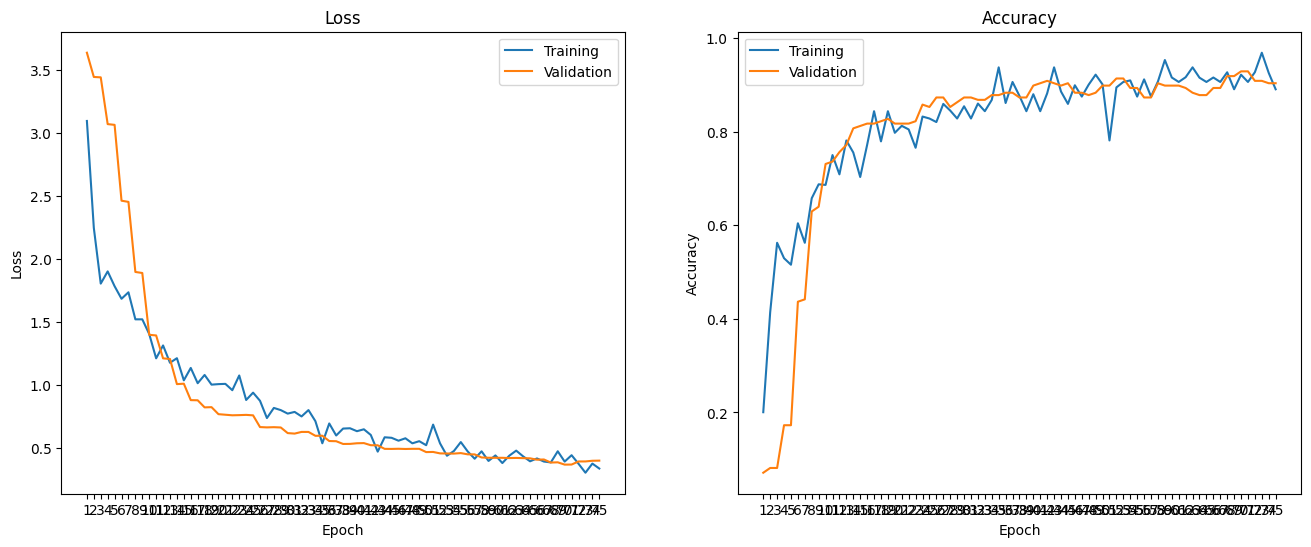

In [410]:
plot_history(histories_3)

In [411]:
y_test_predictions = get_predictions(model3, X_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 172ms/step


In [412]:
unique_labels = np.unique(y_test)
label_map = {label: idx for idx, label in enumerate(unique_labels)}
y_test_mapped = np.array([label_map[y] for y in y_test])

In [413]:
# Calulate the overall accuracy on test set
##### YOUR CODE STARTS #####
test_accuracy = np.mean(y_test_predictions == y_test_mapped)
##### YOUR CODE ENDS #####
print(f'Test accuracy is {test_accuracy:.2f}')

Test accuracy is 0.92


In [414]:
# Accuracy for each individual class on test set
per_class_accuracy_score(y_test_predictions, y_test_mapped)

{np.int64(0): np.float64(1.0),
 np.int64(1): np.float64(0.7142857142857143),
 np.int64(2): np.float64(1.0),
 np.int64(3): np.float64(1.0),
 np.int64(4): np.float64(0.75),
 np.int64(5): np.float64(1.0),
 np.int64(6): np.float64(1.0),
 np.int64(7): np.float64(0.7142857142857143),
 np.int64(8): np.float64(0.9166666666666666),
 np.int64(9): np.float64(1.0),
 np.int64(10): np.float64(1.0),
 np.int64(11): np.float64(0.9333333333333333),
 np.int64(12): np.float64(1.0),
 np.int64(13): np.float64(0.5),
 np.int64(14): np.float64(1.0),
 np.int64(15): np.float64(1.0),
 np.int64(16): np.float64(1.0),
 np.int64(17): np.float64(0.5),
 np.int64(18): np.float64(1.0),
 np.int64(19): np.float64(1.0),
 np.int64(20): np.float64(1.0),
 np.int64(21): np.float64(1.0),
 np.int64(22): np.float64(1.0),
 np.int64(23): np.float64(0.9333333333333333),
 np.int64(24): np.float64(1.0),
 np.int64(25): np.float64(0.875),
 np.int64(26): np.float64(1.0),
 np.int64(27): np.float64(0.0),
 np.int64(28): np.float64(0.0),
 np.

<font color='red'> For how many classes your model showed zero accuracy? Did the performance improve comparing to the original and naively oversampled datasets?


Your answer:

3 classes showed zero accuracy.

performance got better than original and model 2.


# Bonus exercises

**NB, these are optional exercises! You do not have to do them unless you feel like :)**


## Implement Attentive CutMix from scratch (up to 4 bonus points depending on presentation):

<font color=''> Experimentally verify if Attentive CutMix augmentation helps to improve the test score on BelgiumTSC. Link to the Attentive CutMix paper: https://arxiv.org/pdf/2003.13048. Implement and show couple of examples images augmented with Attentive CutMix. Test its performance and visualise the corresponding accuracy and loss curves. Compare the results of model trained on Attentive CutMix augmented images to the model trained with regular data augmentation. </font>


<h1 style="color:red;">I vibe coded this!</h1>
<p style="color:red; font-size:24px;">Please take this code with a grain of salt 🙂</p>


In [ ]:
##### YOUR CODE STARTS #####
...#feel free to use more cells
##### YOUR CODE ENDS #####

In [317]:
# unique labels from oversampled training set
unique_labels = np.unique(y_train_oversampled)
label_map = {label: idx for idx, label in enumerate(unique_labels)}
y_train_mapped = np.array([label_map[y] for y in y_train_oversampled])

num_classes = len(unique_labels)

Epoch 1/5
72/72 ━━━━━━━━━━━━━━━━━━━━ 18s 186ms/step - accuracy: 0.2065 - loss: 3.0560 - val_accuracy: 0.0728 - val_loss: 3.7129
Epoch 2/5
72/72 ━━━━━━━━━━━━━━━━━━━━ 10s 136ms/step - accuracy: 0.4194 - loss: 2.2249 - val_accuracy: 0.0551 - val_loss: 3.6846
Epoch 3/5
72/72 ━━━━━━━━━━━━━━━━━━━━ 10s 135ms/step - accuracy: 0.5410 - loss: 1.8722 - val_accuracy: 0.1161 - val_loss: 3.4935
Epoch 4/5
72/72 ━━━━━━━━━━━━━━━━━━━━ 10s 136ms/step - accuracy: 0.6032 - loss: 1.6641 - val_accuracy: 0.2520 - val_loss: 3.0050
Epoch 5/5
72/72 ━━━━━━━━━━━━━━━━━━━━ 10s 136ms/step - accuracy: 0.6548 - loss: 1.5176 - val_accuracy: 0.4469 - val_loss: 2.4234
Epoch 1/5
loss=3.0727, acc=0.4058, val_loss=1.6747, val_acc=0.8110
Epoch 2/5
loss=2.9205, acc=0.4488, val_loss=1.2379, val_acc=0.9587
Epoch 3/5
loss=2.7824, acc=0.4919, val_loss=1.0412, val_acc=0.9862
Epoch 4/5
loss=2.7652, acc=0.5000, val_loss=1.0760, val_acc=0.9902
Epoch 5/5
loss=2.6964, acc=0.5173, val_loss=0.8116, val_acc=0.9941
Attentive CutMix Test Acc

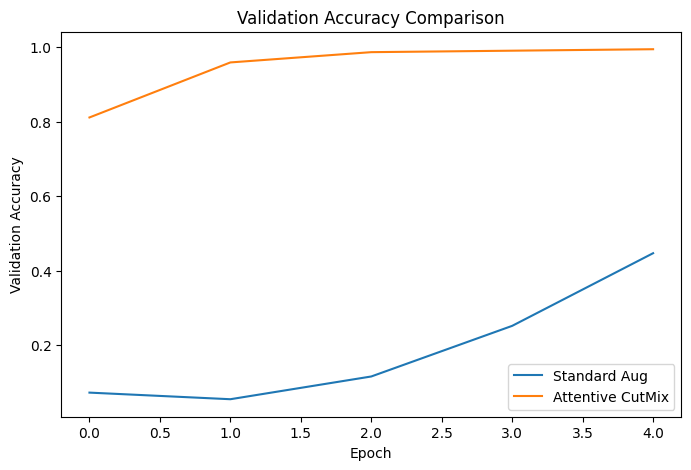

In [324]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation, MaxPooling2D, Dropout, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split

# ===============================
# 0. Map oversampled labels to 0..num_classes-1
# ===============================
unique_labels = np.unique(y_train_oversampled)
label_map = {label: idx for idx, label in enumerate(unique_labels)}
y_train_mapped = np.array([label_map[y] for y in y_train_oversampled])
num_classes = len(unique_labels)

# ===============================
# 1. Build the base model
# ===============================
def build_model():
    x = Input(shape=(100, 100, 3), name="input_layer")
    # First conv block
    c1 = Conv2D(32, (3,3), padding="same")(x)
    b1 = BatchNormalization()(c1)
    a1 = Activation("relu")(b1)

    # Second conv block
    c2 = Conv2D(32, (3,3), padding="same")(a1)
    b2 = BatchNormalization()(c2)
    a2 = Activation("relu")(b2)

    # Third conv block (named for attention)
    c3 = Conv2D(32, (3,3), padding="valid", name="conv_last")(a2)
    b3 = BatchNormalization()(c3)
    a3 = Activation("relu")(b3)

    p3 = MaxPooling2D(pool_size=2)(a3)
    d3 = Dropout(0.25)(p3)

    # Flatten + dense
    f = Flatten()(d3)
    h = Dense(100)(f)
    b4 = BatchNormalization()(h)
    a4 = Activation("relu")(b4)
    d4 = Dropout(0.5)(a4)

    # Output layer
    z = Dense(num_classes)(d4)
    p = Activation("softmax")(z)

    model = Model(inputs=x, outputs=p)
    model.compile(
        loss='categorical_crossentropy',
        optimizer=Adam(1e-4),
        metrics=['accuracy']
    )
    return model

model = build_model()

# ===============================
# 2. Standard data augmentation pre-training
# ===============================
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

batch_size = 64

X_train_part, X_val, y_train_part, y_val = train_test_split(
    X_train_oversampled, y_train_mapped, test_size=0.1, stratify=y_train_mapped, random_state=42
)

train_gen = datagen.flow(X_train_part, to_categorical(y_train_part, num_classes), batch_size=batch_size)
val_gen   = datagen.flow(X_val, to_categorical(y_val, num_classes), batch_size=batch_size)

history_std = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5
)

# ===============================
# 3. Attentive CutMix utilities
# ===============================
def compute_attention_map(model, image, layer_name='conv_last'):
    feature_extractor = tf.keras.Model(
        inputs=model.inputs,
        outputs=model.get_layer(layer_name).output
    )
    fmap = feature_extractor(np.expand_dims(image, axis=0))
    fmap = tf.reduce_mean(fmap, axis=-1)[0]
    fmap = (fmap - tf.reduce_min(fmap)) / (tf.reduce_max(fmap) - tf.reduce_min(fmap) + 1e-8)
    return fmap.numpy()

def attentive_cutmix_pair(source_img, target_img, source_label, target_label, attention_map, beta=1.0):
    h, w, _ = source_img.shape
    lam = np.random.beta(beta, beta)
    grid_size = 7
    cell_h, cell_w = h // grid_size, w // grid_size
    att_cells = attention_map.reshape((grid_size, cell_h, grid_size, cell_w))
    att_sum = np.sum(att_cells, axis=(1,3))
    top_i, top_j = np.unravel_index(np.argmax(att_sum), att_sum.shape)
    y1, x1 = top_i * cell_h, top_j * cell_w
    y2, x2 = y1 + cell_h, x1 + cell_w
    new_img = target_img.copy()
    new_img[y1:y2, x1:x2, :] = source_img[y1:y2, x1:x2, :]
    new_label = lam * source_label + (1-lam) * target_label
    return new_img, new_label

def generate_attentive_cutmix_batch(X, y_mapped, model_for_attention, batch_size=32, beta=1.0):
    idx = np.random.choice(len(X), size=batch_size*2, replace=True)
    X1, X2 = X[idx[:batch_size]], X[idx[batch_size:]]
    y1, y2 = to_categorical(y_mapped[idx[:batch_size]], num_classes), to_categorical(y_mapped[idx[batch_size:]], num_classes)
    X_new = np.zeros_like(X1)
    y_new = np.zeros_like(y1)
    for i in range(batch_size):
        att_map = compute_attention_map(model_for_attention, X1[i])
        X_new[i], y_new[i] = attentive_cutmix_pair(X1[i], X2[i], y1[i], y2[i], att_map, beta=beta)
    return X_new, y_new

# ===============================
# 4. Train with Attentive CutMix
# ===============================
num_epochs = 5
steps_per_epoch = len(X_train_oversampled) // batch_size
history_attentive = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}

for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}/{num_epochs}")
    for step in range(steps_per_epoch):
        X_batch, y_batch = generate_attentive_cutmix_batch(
            X_train_oversampled, y_train_mapped, model_for_attention=model, batch_size=batch_size
        )
        loss, acc = model.train_on_batch(X_batch, y_batch)

    val_loss, val_acc = model.evaluate(X_val, to_categorical(y_val, num_classes), verbose=0)
    history_attentive['loss'].append(loss)
    history_attentive['accuracy'].append(acc)
    history_attentive['val_loss'].append(val_loss)
    history_attentive['val_accuracy'].append(val_acc)
    print(f"loss={loss:.4f}, acc={acc:.4f}, val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")

# ===============================
# 5. Evaluate on test set
# ===============================
y_test_mapped = np.array([label_map[y] for y in y_test])
test_loss, test_acc = model.evaluate(X_test, to_categorical(y_test_mapped, num_classes), verbose=0)
print("Attentive CutMix Test Accuracy:", test_acc)

# ===============================
# 6. Visualize
# ===============================
plt.figure(figsize=(8,5))
plt.plot(history_std.history['val_accuracy'], label='Standard Aug')
plt.plot(history_attentive['val_accuracy'], label='Attentive CutMix')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy Comparison')
plt.legend()
plt.show()


<font color='red'> Please, keep in mind that we expect a lot from the bonus exercise solutions. In order to claim all points the solution must resemble a blog post with examples, figures, explanations, reasoning and nicely documented code.


# Comments (optional feedback to the course instructors)

Here, please, leave your comments regarding the homework, possibly answering the following questions:

-   how much time did you send on this homework? too much
-   was it too hard/easy for you? REALLY DIFFICULT ;(
-   what would you suggest to add or remove? add more hints for exercises
-   anything else you would like to tell us


Your comments:


# <font color='red'> End of the homework. Please don't delete this cell.</font>
